In [25]:
import numpy as np
import glob
from meer21cm.stack import sum_3d_stack
from meer21cm.util import rebin_spectrum
import matplotlib.pyplot as plt
from meer21cm import PowerSpectrum
from meer21cm.telescope import dish_beam_sigma
from meer21cm.plot import plot_map
from meer21cm.util import jy_to_kelvin, pca_clean, rebin_spectrum, center_to_edges
from meer21cm.stack import stack, sum_3d_stack
import matplotlib as mpl

# === Plot config ===
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.bottom": True,
    "xtick.top": False,
    "ytick.left": True,
    "ytick.right": False,
    "axes.grid": True,
    "grid.linestyle": "--",  # 设置为虚线
})

raminGAMA,ramaxGAMA = 339,351
decminGAMA,decmaxGAMA = -35,-30
ra_range_GAMA = (raminGAMA,ramaxGAMA)
dec_range_GAMA = (decminGAMA,decmaxGAMA)
raminMK,ramaxMK = 334,357
decminMK,decmaxMK = -35,-26.5
ra_range_MK = (raminMK,ramaxMK)
dec_range_MK = (decminMK,decmaxMK)

cosmo='Planck18'
file_dir = '/idia/projects/meerklass/MEERKLASS-2/Lband_2021/level6/'
fits_file = file_dir+'Nscan961_Tsky_cube_p0.3d_sigma4.0_iter2.fits'
counts_file = file_dir+'Nscan961_Npix_count_cube_p0.3d_sigma4.0_iter2.fits'
gal_file = 'G23TilingCatv11.fits'

vel_max=6500
symmetrize = True

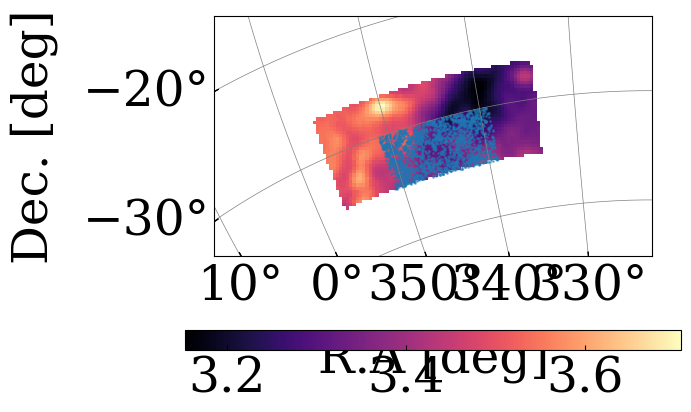

In [26]:
ps = PowerSpectrum(
    survey='meerklass_2021',
    band='L',
    map_file=fits_file,
    counts_file=counts_file,
    cosmo=cosmo,
    gal_file=gal_file,
    ra_range = ra_range_MK,
    dec_range = dec_range_MK,
)
ps.read_from_fits()
ps.ra_range = ra_range_GAMA
ps.dec_range = dec_range_GAMA
ps.read_gal_cat()
ps.ra_range = ra_range_MK
ps.dec_range = dec_range_MK
plot_map(ps.data,ps.wproj,W=ps.W_HI)
ax = plt.gca()
ax.scatter(
    ps.ra_gal,ps.dec_gal,
    transform=ax.get_transform('world'),
    s=1,alpha=0.5)

In [19]:
# convert to Jy
jy_k_coeff = jy_to_kelvin(1,ps.pixel_area*(np.pi/180)**2,ps.nu)
#PCA cleaning
hi_map_clean_data,A_mat_data = pca_clean(ps.data/jy_k_coeff[None,None],10,weights=ps.W_HI,mean_center=True,return_A=True)
ps.data = hi_map_clean_data

In [28]:
np.shape(A_mat_data)

(252, 10)

In [20]:
#stacking
stack_3D_map, stack_3D_weight = stack(
    ps,
    symmetrize=symmetrize,
)

In [21]:
angular_stack_osci_data,spectral_stack_osci_data = sum_3d_stack(
        stack_3D_map,ang_sum_dist=1.0/0.3
    )
spectral_stack_rebin_osci_data = rebin_spectrum(spectral_stack_osci_data)

In [22]:
ang_edges = np.linspace(-10,10,21)*ps.pix_resol
x_edges = np.linspace(0,2*ps.nu.size,2*ps.nu.size+1)*ps.vel_resol
x_edges -= x_edges[x_edges.size//2]
x_edges = center_to_edges(x_edges)
# x_bins
vel_bin = (x_edges[1:]+x_edges[:-1])/2
x_rebin = center_to_edges(rebin_spectrum(vel_bin))

In [23]:
def vel_to_freq(vel):
    return vel / ps.vel_resol * ps.freq_resol /1e6

def freq_to_vel(freq):
    return freq / ps.freq_resol * ps.vel_resol * 1e6

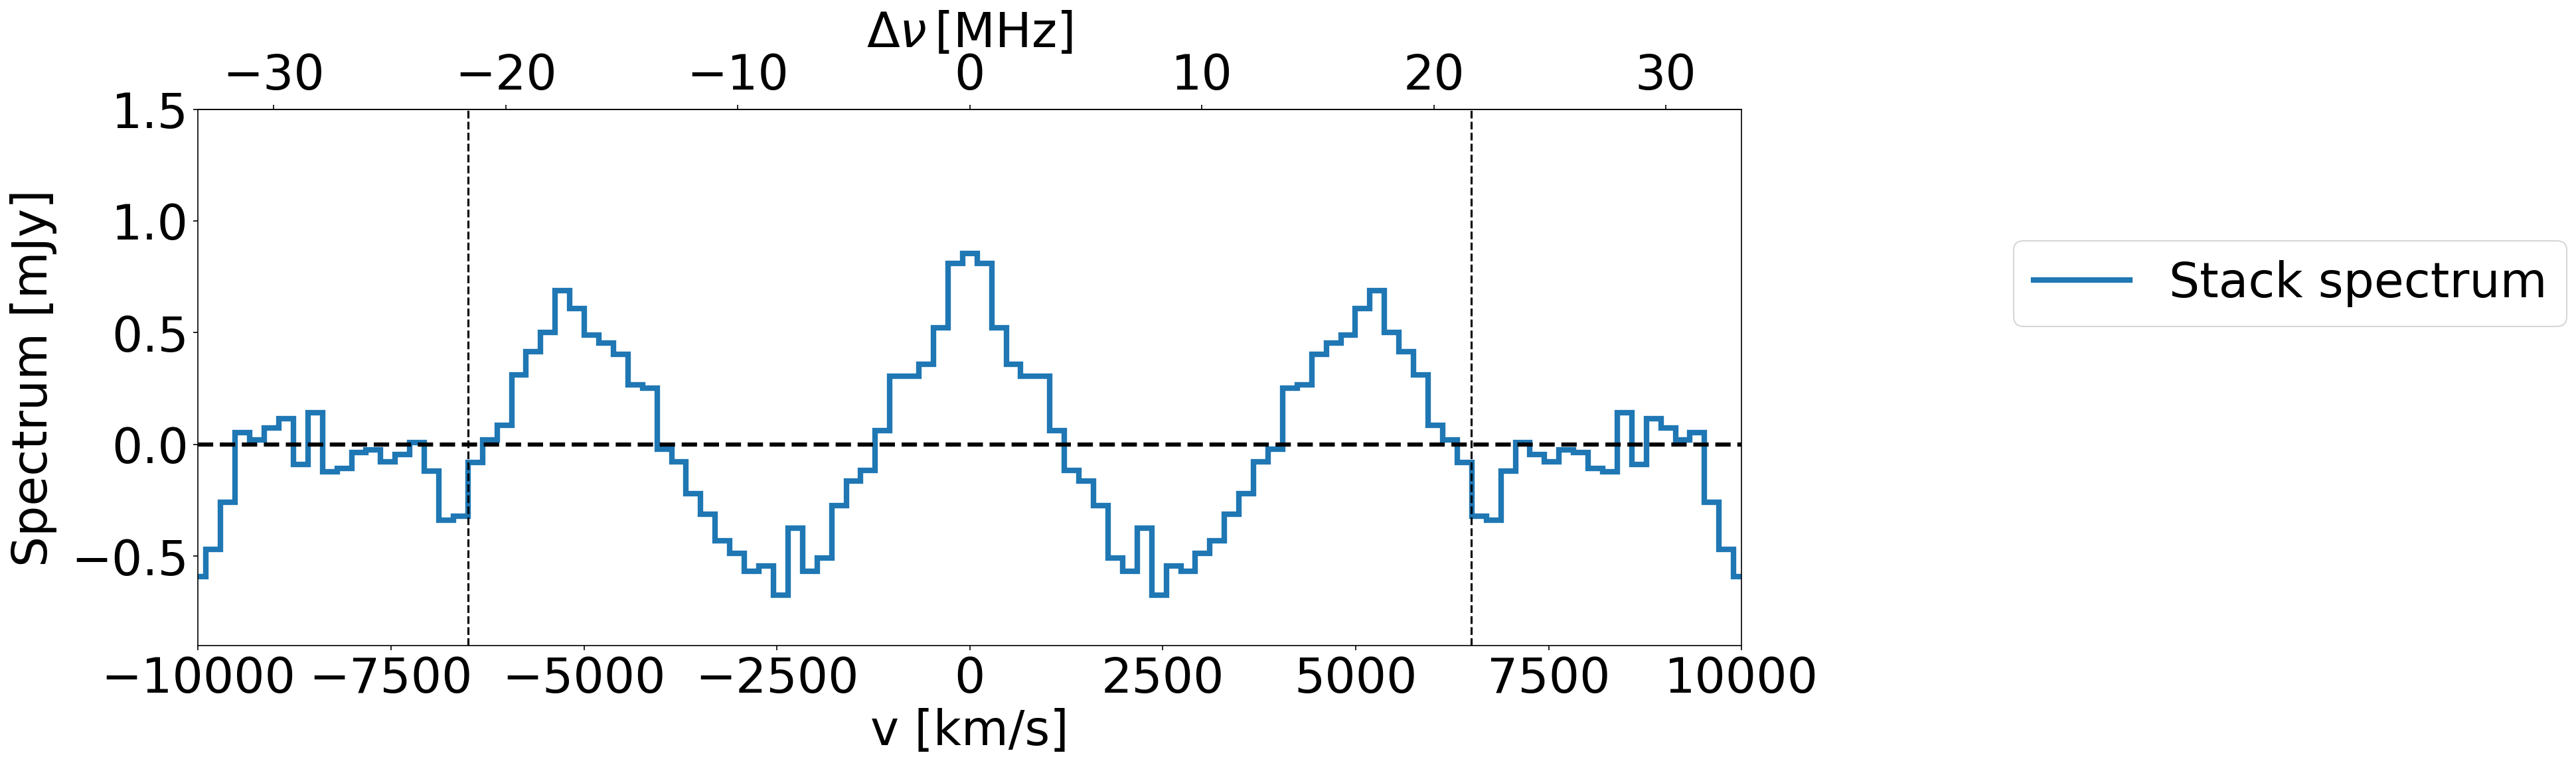

In [24]:
plt.rcParams.update({'font.size':35})

fig,axes=plt.subplots(1,1,sharex=True,dpi=150,figsize=(20,7))
ax = axes
ax.stairs((spectral_stack_rebin_osci_data)*1e3,x_rebin,label='Stack spectrum',lw=4,ls='-',
          #color='black'
         )
ax.axvline(vel_max,color='black',ls='--')
ax.axvline(-vel_max,color='black',ls='--')
ax.axhline(0.0,color='black',ls='--',lw=3)

#ax.stairs(spectral_stack_data*1e3,x_rebin,label='Data',lw=4,ls='--')

#ax.stairs(hisim.hi_profile_mock_tracer.mean(axis=-1)*1e3,vel_profile,label='input',lw=4, ls='--')

secax = ax.secondary_xaxis('top', functions=(vel_to_freq, freq_to_vel))
secax.set_xlabel(r'$\Delta \nu \,$[MHz]')

ax.set_xlim(-10000,10000)
ax.set_ylim(-0.9,1.5)
#ax.axvline(1800)
ax.set_xlabel('v [km/s]')
ax.set_ylabel('Spectrum [mJy]',labelpad=10.0)
ax.legend(loc='upper right',bbox_to_anchor=[1.55,0.8])